# IMPORT LIBRARIES

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# LOAD DATASETS

In [162]:
Dim_Customers = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Dim_Customers_2026-05-08.csv")
Dim_Date = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Dim_Date_2026-05-08.csv")
Dim_Products = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Dim_Products_2026-05-08.csv")
Dim_Sellers = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Dim_Sellers_2026-05-08.csv")
Fact_Orders = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Fact_Orders_2026-05-08.csv")
Fact_Orders_Items = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Fact_Order_Items_2026-05-08.csv")
Fact_Marketing = pd.read_csv("D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Fact_Marketing_Funnel_2026-05-08.csv")

# EDA

## Dim_Customers

In [163]:
print("--- Missing Values ---")
print(Dim_Customers.isnull().sum())
print(f"\nTotal Duplicate Customer IDs: {Dim_Customers['customer_unique_id'].duplicated().sum()}")

--- Missing Values ---
customer_unique_id       0
zip_code                 0
city                     0
state                    0
latitude               268
longitude              268
load_date_timestamp      0
dtype: int64

Total Duplicate Customer IDs: 0


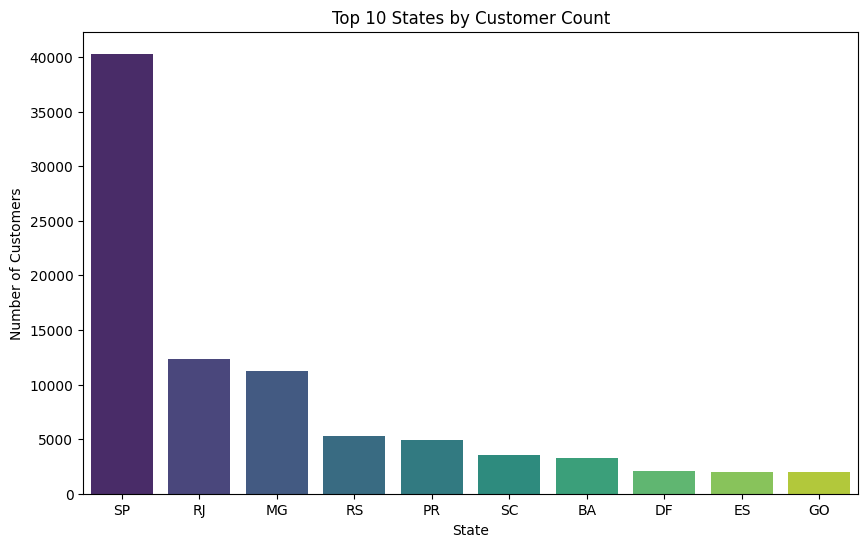

In [164]:
top_states = Dim_Customers['state'].value_counts().head(10).reset_index()
top_states.columns = ['state', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_states, x='state', y='count', palette='viridis')
plt.title('Top 10 States by Customer Count')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

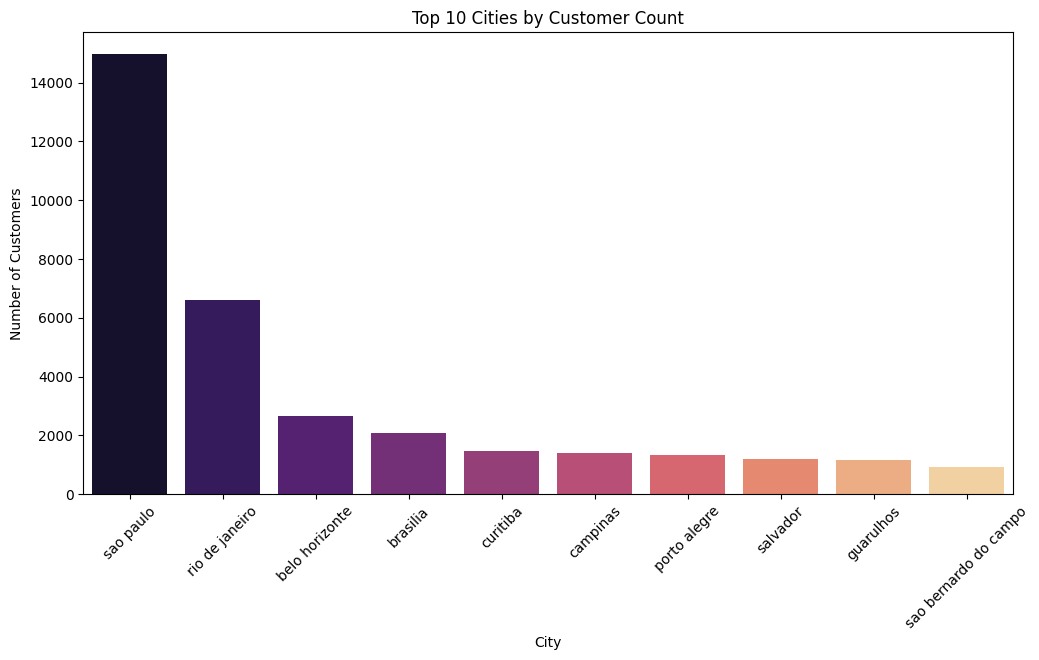

In [165]:
top_cities = Dim_Customers['city'].value_counts().head(10).reset_index()
top_cities.columns = ['city', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cities, x='city', y='count', palette='magma')
plt.title('Top 10 Cities by Customer Count')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

## Dim_Products

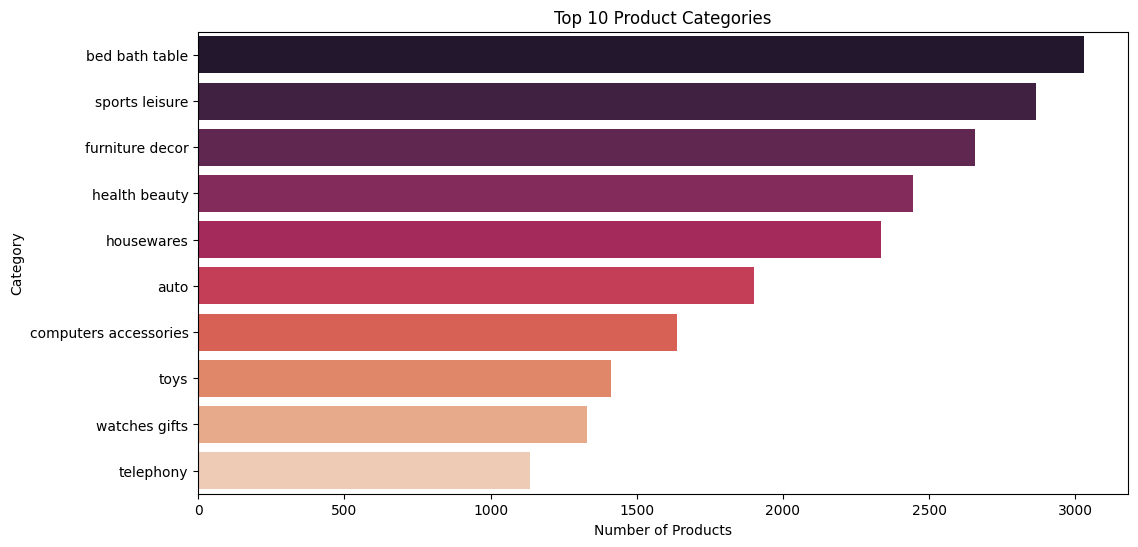

In [166]:
top_categories = Dim_Products['category_name_en'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='rocket')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

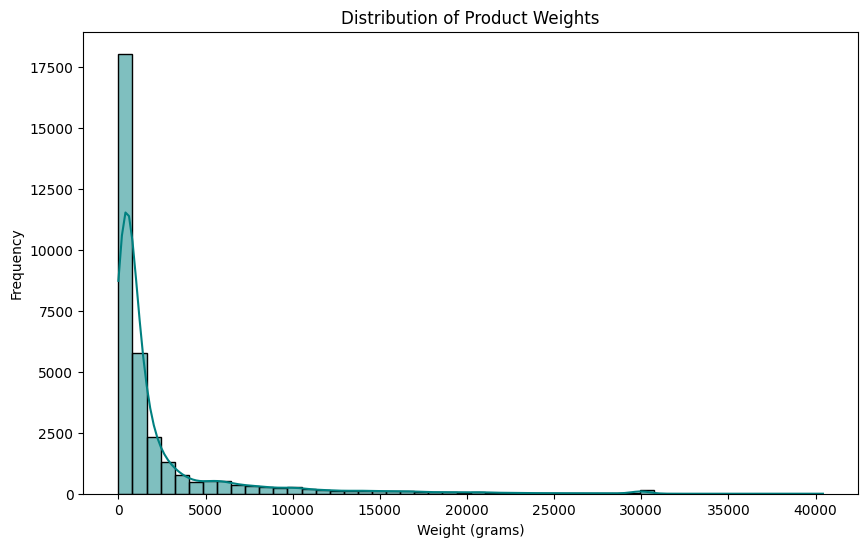

In [167]:
plt.figure(figsize=(10, 6))
sns.histplot(Dim_Products['weight_g'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Product Weights')
plt.xlabel('Weight (grams)')
plt.ylabel('Frequency')
plt.show()

In [168]:
print("Missing Values Summary:")
print(Dim_Products.isnull().sum())

Missing Values Summary:
product_id               0
category_name_pt       610
category_name_en       623
name_length            610
description_length     610
photo_count            610
weight_g                 2
length_cm                2
height_cm                2
width_cm                 2
volume_cm3               2
load_date_timestamp      0
dtype: int64


## Dim_Sellers

In [169]:
print("--- Missing Values Percentage ---")
missing_pct = (Dim_Sellers.isnull().sum() / len(Dim_Sellers)) * 100
print(missing_pct.round(2).astype(str) + '%')

--- Missing Values Percentage ---
seller_id                     0.0%
zip_code                      0.0%
city                         0.06%
state                         0.0%
latitude                     1.36%
longitude                    1.36%
business_segment            87.72%
business_type               87.82%
lead_type                   87.82%
behaviour_profile           90.66%
catalog_size                100.0%
declared_monthly_revenue    87.72%
came_from_marketing           0.0%
load_date_timestamp           0.0%
dtype: object


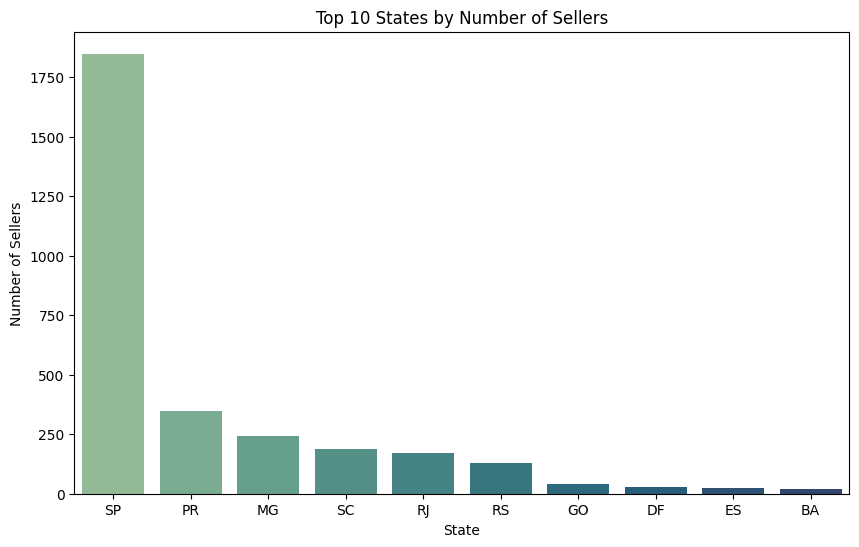

In [170]:
top_seller_states = Dim_Sellers['state'].value_counts().head(10).reset_index()
top_seller_states.columns = ['state', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_seller_states, x='state', y='count', palette='crest')
plt.title('Top 10 States by Number of Sellers')
plt.xlabel('State')
plt.ylabel('Number of Sellers')
plt.show()

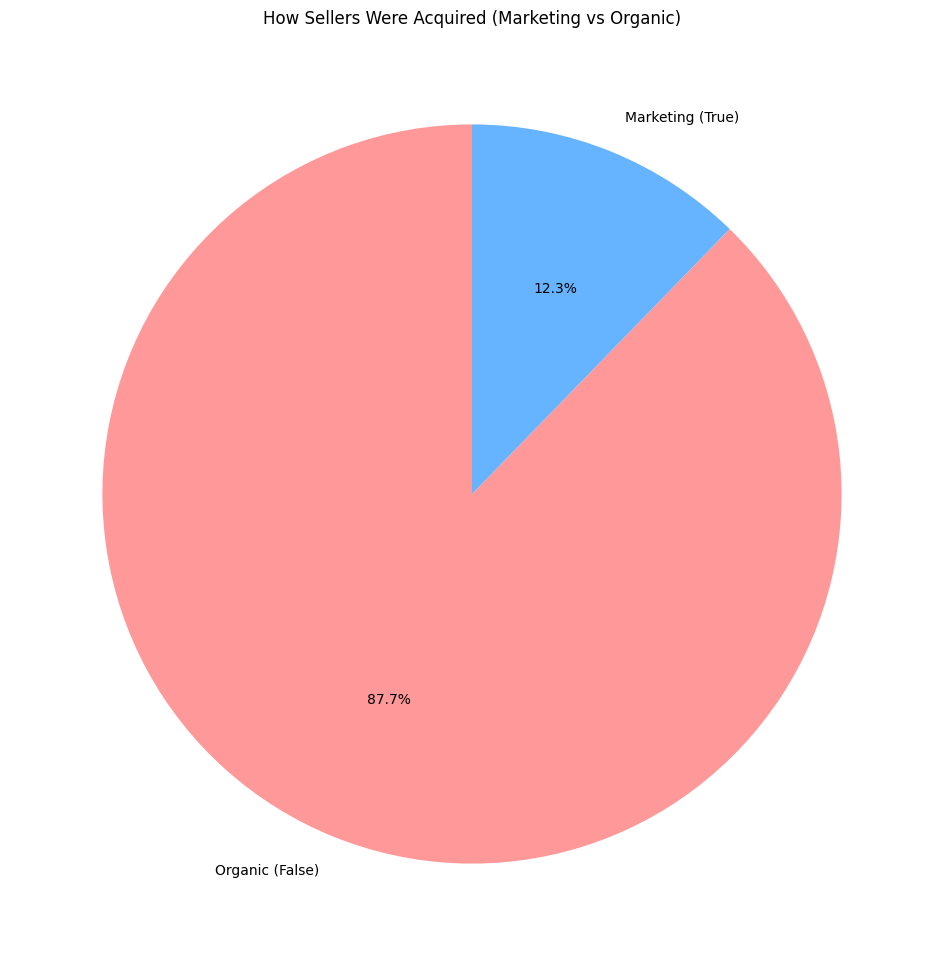

In [171]:
marketing_counts = Dim_Sellers['came_from_marketing'].value_counts()

plt.figure(figsize=(15, 12))
plt.pie(marketing_counts, labels=['Organic (False)', 'Marketing (True)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('How Sellers Were Acquired (Marketing vs Organic)')
plt.show()

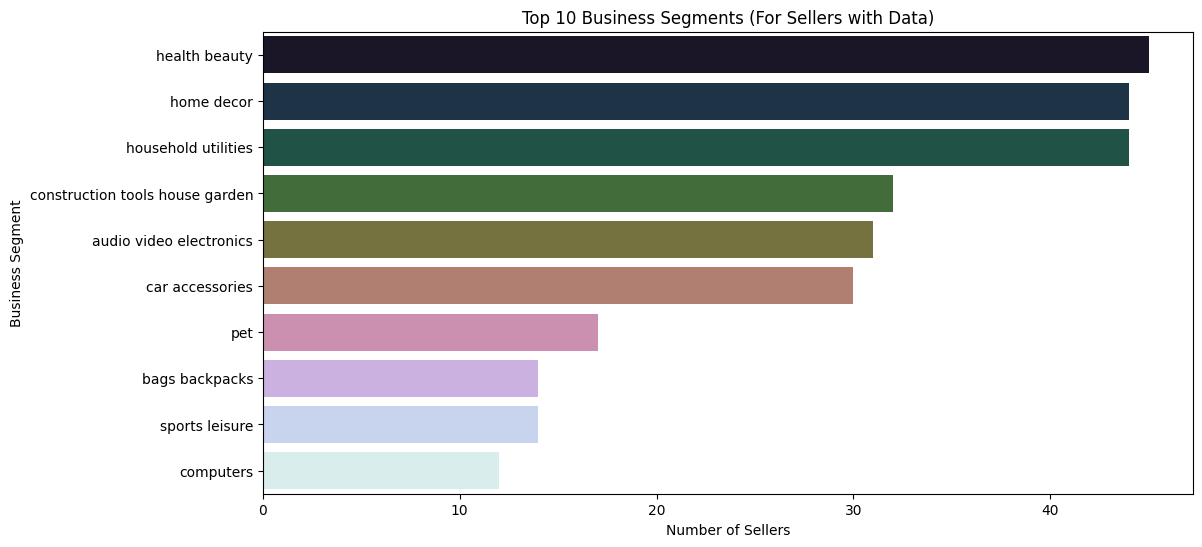

In [172]:
business_segments = Dim_Sellers['business_segment'].dropna().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=business_segments.values, y=business_segments.index, palette='cubehelix')
plt.title('Top 10 Business Segments (For Sellers with Data)')
plt.xlabel('Number of Sellers')
plt.ylabel('Business Segment')
plt.show()

## Fact_Orders

create scatter plot reviews score and add lable positive and negative score and show  order late and i need know review score decrease or not 

In [173]:
print("--- Missing Values ---")
print(Fact_Orders.isnull().sum())

--- Missing Values ---
order_id                    0
customer_unique_id          0
purchase_date_key           0
order_status                0
total_payment               1
primary_payment_type        1
review_score            34392
review_text             72626
delivery_days_actual     2965
is_late_delivery         2965
is_invalid_payment          0
load_date_timestamp         0
dtype: int64


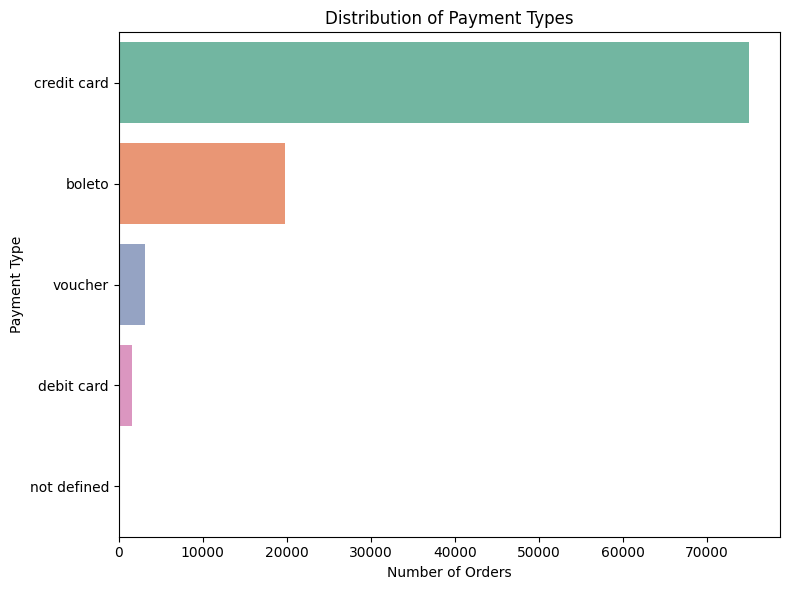

In [174]:
plt.figure(figsize=(8, 6))
sns.countplot(data=Fact_Orders, y='primary_payment_type', order=Fact_Orders['primary_payment_type'].value_counts().index, palette='Set2')
plt.title('Distribution of Payment Types')
plt.xlabel('Number of Orders')
plt.ylabel('Payment Type')
plt.tight_layout()
plt.show()

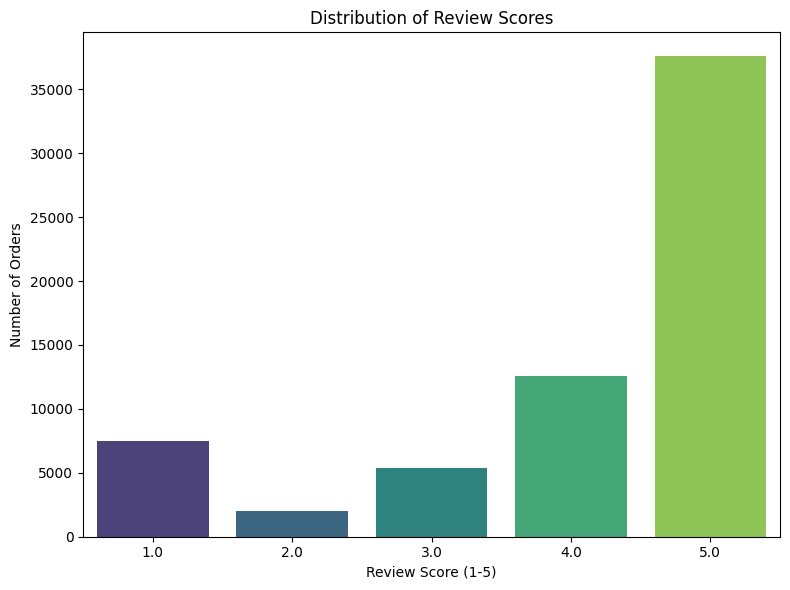

In [175]:
plt.figure(figsize=(8, 6))
sns.countplot(data=Fact_Orders, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

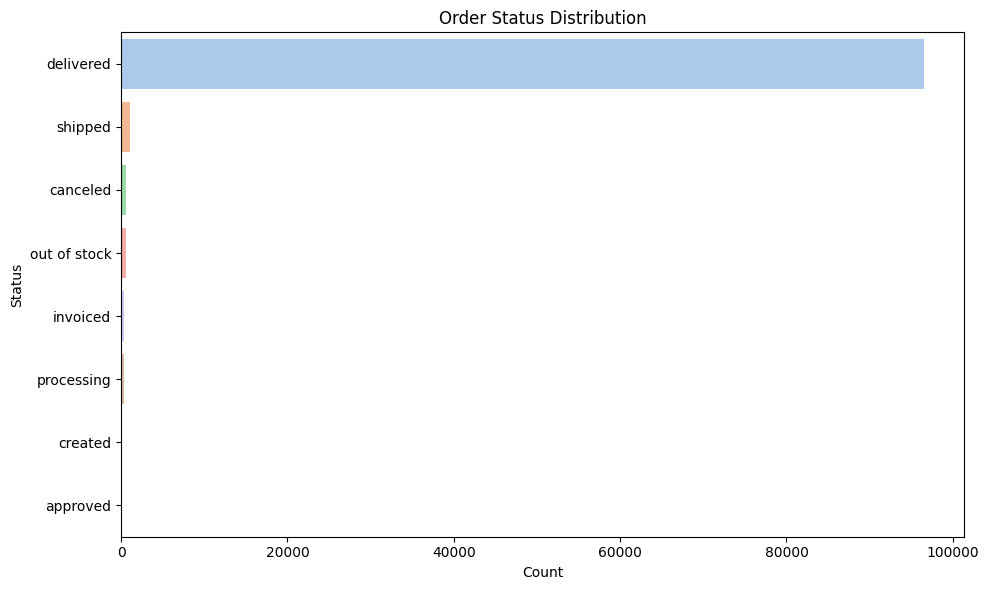

In [176]:
plt.figure(figsize=(10, 6))
sns.countplot(data=Fact_Orders, y='order_status', order=Fact_Orders['order_status'].value_counts().index, palette='pastel')
plt.title('Order Status Distribution')
plt.xlabel('Count')
plt.ylabel('Status')
plt.tight_layout()
plt.show()

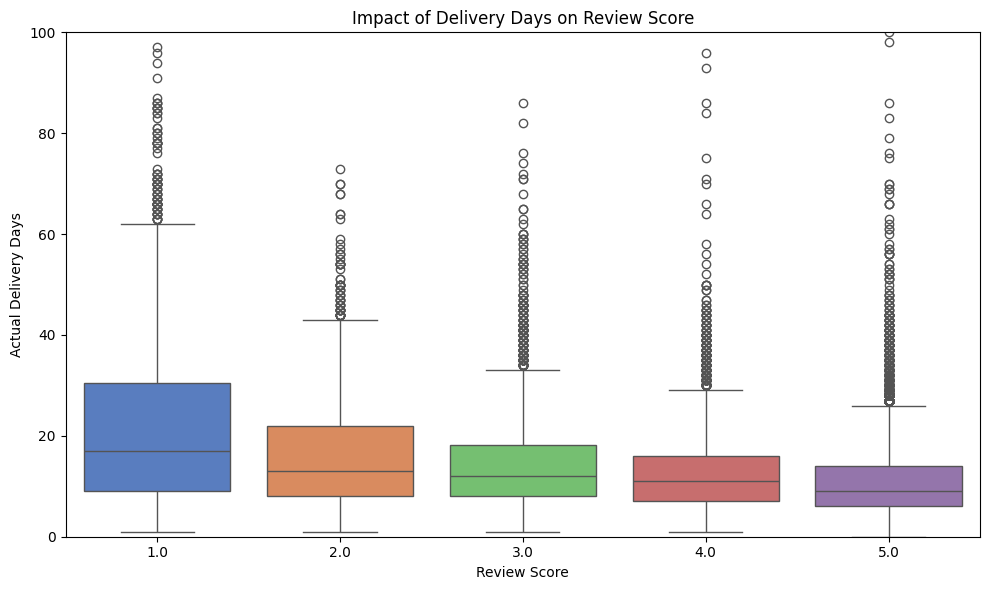

In [177]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=Fact_Orders, x='review_score', y='delivery_days_actual', palette='muted')
plt.title('Impact of Delivery Days on Review Score')
plt.xlabel('Review Score')
plt.ylabel('Actual Delivery Days')
plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

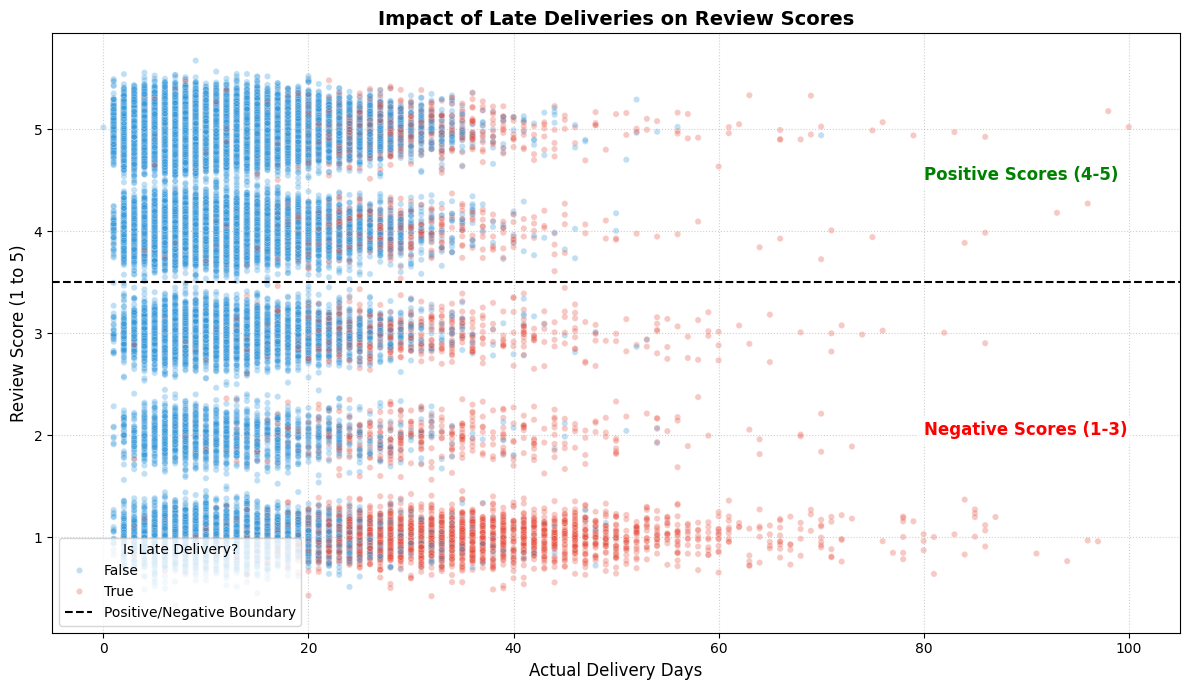

In [178]:
np.random.seed(42)
Fact_Orders['review_score_jitter'] = Fact_Orders['review_score'] + np.random.normal(0, 0.15, size=len(Fact_Orders))

# 4. إعداد الرسم البياني
plt.figure(figsize=(12, 7))

# تجاهل القيم المتطرفة جداً (أكثر من 100 يوم) لتوضيح الرسم
df_plot = Fact_Orders[Fact_Orders['delivery_days_actual'] <= 100]

sns.scatterplot(
    data=df_plot,
    x='delivery_days_actual',
    y='review_score_jitter',
    hue='is_late_delivery',
    palette={True: '#e74c3c', False: '#3498db'}, # أحمر للمتأخر، أزرق للمنتظم
    alpha=0.3,
    s=20
)

# 5. إضافة الخطوط الفاصلة والنصوص التوضيحية
plt.axhline(3.5, color='black', linestyle='--', linewidth=1.5, label='Positive/Negative Boundary')

plt.text(x=80, y=4.5, s='Positive Scores (4-5)', fontsize=12, color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.text(x=80, y=2.0, s='Negative Scores (1-3)', fontsize=12, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.title('Impact of Late Deliveries on Review Scores', fontsize=14, fontweight='bold')
plt.xlabel('Actual Delivery Days', fontsize=12)
plt.ylabel('Review Score (1 to 5)', fontsize=12)
plt.yticks([1, 2, 3, 4, 5])
plt.legend(title='Is Late Delivery?', loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Customer Type Summary by Year:


Type,One-time Customer,Repeat Customer,Total Customers,Repeat %
year,,,,
2016,323,3,326,0.9
2017,42457,1256,43713,2.9
2018,51582,1167,52749,2.2


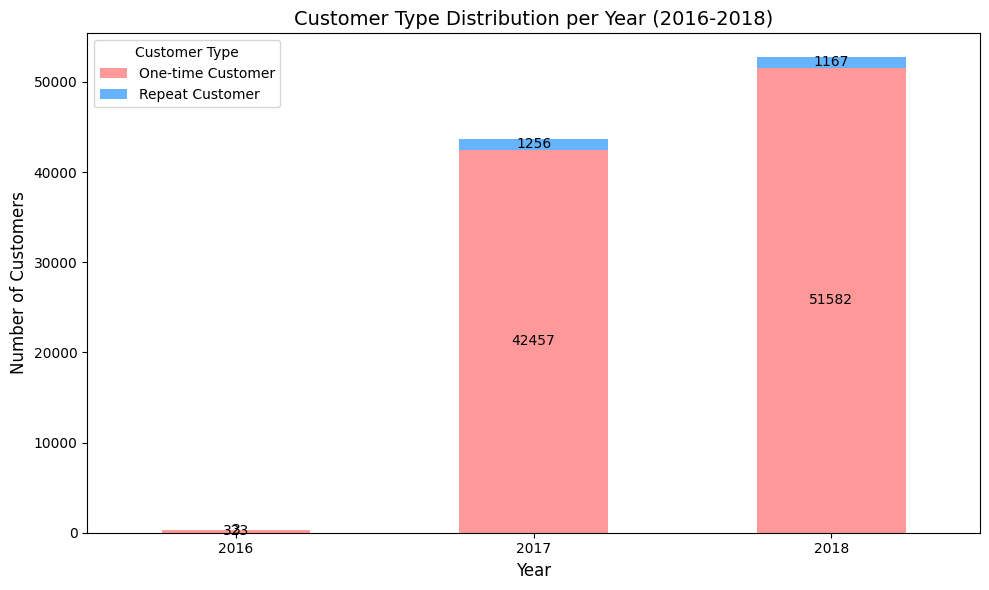

In [190]:
# 1. Identify the correct date column and convert it to datetime format
date_columns = ['purchase_date_key', 'order_purchase_timestamp', 'purchase_timestamp', 'order_purchase_date']
date_col = next((col for col in date_columns if col in Fact_Orders.columns), None)

if date_col is None:
    raise KeyError(f"No known purchase date column found. Tried: {', '.join(date_columns)}")

if date_col == 'purchase_date_key':
    raw_dates = pd.read_csv(
        r'D:\mohanad study\ERU Study\level 3\semester 2\Predictive Analytics\project\GoldExports\Gold_Fact_Orders_2026-05-08.csv',
        usecols=[date_col]
    )[date_col]
    Fact_Orders[date_col] = pd.to_datetime(
        raw_dates.astype(str),
        format='%Y%m%d',
        errors='coerce'
    )
else:
    Fact_Orders[date_col] = pd.to_datetime(Fact_Orders[date_col], errors='coerce')

if Fact_Orders[date_col].isna().all():
    raise ValueError(f"All values in '{date_col}' could not be parsed as datetimes.")

Fact_Orders['year'] = Fact_Orders[date_col].dt.year

# 2. Define Customer Identity (customer_unique_id is preferred for repeat customer analysis)
cust_col = 'customer_unique_id' if 'customer_unique_id' in Fact_Orders.columns else 'customer_id'

# 3. Calculate number of orders per customer per year
customer_year_counts = (
    Fact_Orders.dropna(subset=['year', cust_col])
    .groupby(['year', cust_col])
    .size()
    .reset_index(name='order_count')
)

# 4. Categorize customers for each year
customer_year_counts['Type'] = customer_year_counts['order_count'].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

# 6. Prepare data for Stacked Column Chart
selected_years = [2016, 2017, 2018]
pivot_data = customer_year_counts.groupby(['year', 'Type']).size().unstack(fill_value=0)
pivot_data = pivot_data.reindex(selected_years, fill_value=0)

# 6b. Display a summary table for the chart
summary_table = pivot_data.copy()
summary_table['Total Customers'] = summary_table.sum(axis=1)
summary_table['Repeat %'] = (summary_table.get('Repeat Customer', 0) / summary_table['Total Customers'] * 100).round(1)
print('Customer Type Summary by Year:')
display(summary_table)

# 7. Plot Stacked Column Chart
ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])

# Add labels and styling
plt.title('Customer Type Distribution per Year (2016-2018)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Customer Type')
plt.xticks(rotation=0)

# Add data labels on top of bars for clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{int(height)}', ha='center', va='center')

plt.tight_layout()
plt.show()

Donut summary uses the same 2016-2018 year-specific repeat definition as the table: 2426 repeat of 96788 total customers (2.5% repeat).


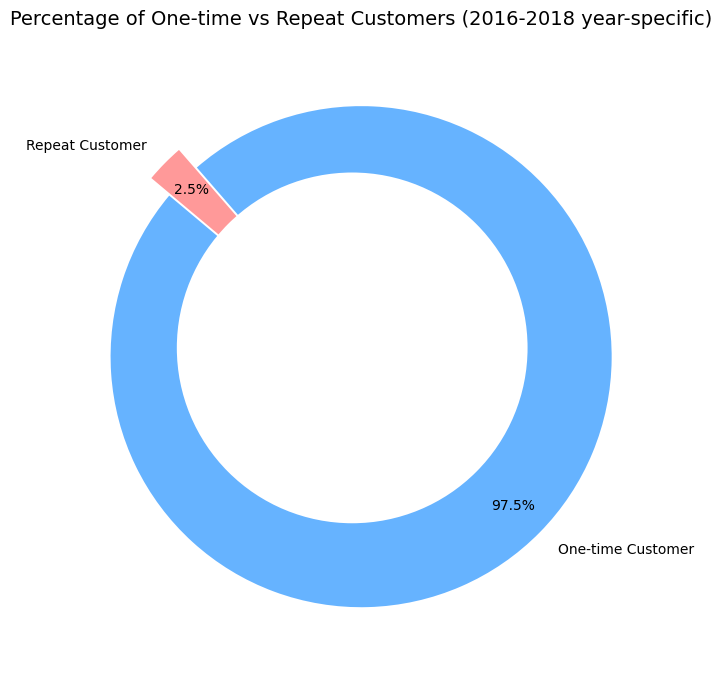

In [191]:
# 1. Calculate the number of orders per unique customer within the same year
# This matches the year-by-year repeat classification used in the summary table.
cust_col = 'customer_unique_id' if 'customer_unique_id' in Fact_Orders.columns else 'customer_id'

yearly_customer_orders = (
    Fact_Orders.dropna(subset=['year', cust_col])
    .loc[Fact_Orders['year'].isin(selected_years)]
    .groupby(['year', cust_col])
    .size()
    .reset_index(name='order_count')
)

# 2. Categorize customers per year: repeat if they ordered more than once within that year
yearly_customer_orders['type'] = yearly_customer_orders['order_count'].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

# 3. Aggregate the same year-specific classification to one overall donut summary
summary = yearly_customer_orders['type'].value_counts().reindex(['One-time Customer', 'Repeat Customer'], fill_value=0)
labels = summary.index
sizes = summary.values
colors = ['#66b3ff', '#ff9999']

print(f"Donut summary uses the same 2016-2018 year-specific repeat definition as the table: {summary['Repeat Customer']} repeat of {summary.sum()} total customers ({summary['Repeat Customer'] / summary.sum() * 100:.1f}% repeat).")

# 4. Generate the Donut Chart
plt.figure(figsize=(7, 7))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85, 
    explode=(0.05, 0.05)
)

# Create the "Donut" effect by adding a white circle at the center
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set chart title and layout
plt.title('Percentage of One-time vs Repeat Customers (2016-2018 year-specific)', fontsize=14)
plt.axis('equal')  
plt.tight_layout()
plt.show()

## Fact_Orders_Items

In [181]:
print("--- Missing Values ---")
print(Fact_Orders_Items.isnull().sum())

--- Missing Values ---
order_item_key                      0
order_id                            0
product_id                          0
seller_id                           0
purchase_date_key                   0
order_purchase_timestamp            0
order_delivered_customer_date    2454
price                               0
freight_value                       0
total_item_value                    0
load_date_timestamp                 0
dtype: int64


In [182]:
print("\n--- Summary Statistics ---")
print(Fact_Orders_Items[['price', 'freight_value', 'total_item_value']].describe())


--- Summary Statistics ---
               price  freight_value  total_item_value
count  112650.000000  112650.000000     112650.000000
mean      120.653739      19.990320        140.644059
std       183.633928      15.806405        190.724394
min         0.850000       0.000000          6.080000
25%        39.900000      13.080000         55.220000
50%        74.990000      16.260000         92.320000
75%       134.900000      21.150000        157.937500
max      6735.000000     409.680000       6929.310000


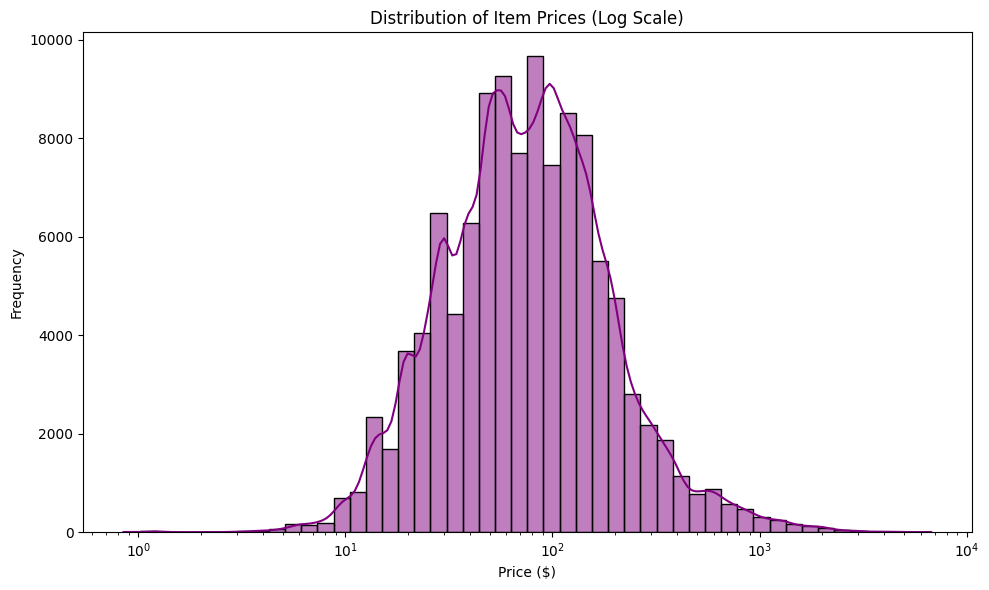

In [183]:
plt.figure(figsize=(10, 6))
sns.histplot(Fact_Orders_Items['price'], bins=50, kde=True, color='purple', log_scale=True)
plt.title('Distribution of Item Prices (Log Scale)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

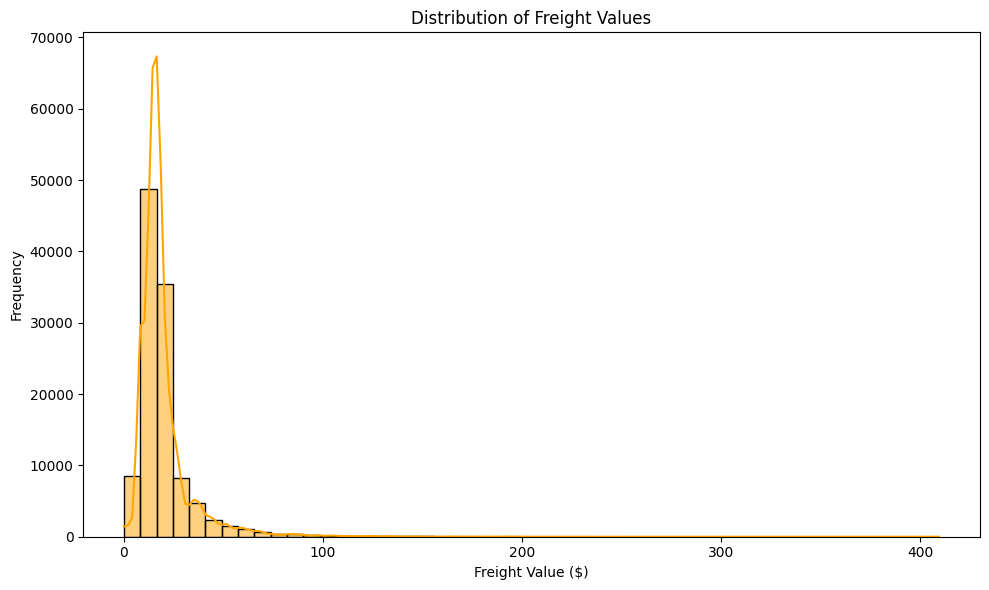

In [184]:
plt.figure(figsize=(10, 6))
sns.histplot(Fact_Orders_Items['freight_value'], bins=50, kde=True, color='orange')
plt.title('Distribution of Freight Values')
plt.xlabel('Freight Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Fact_Marketing

In [185]:
print("--- Missing Values ---")
print(Fact_Marketing.isnull().sum())

--- Missing Values ---
mql_id                       0
seller_id                 7620
first_contact_date_key       0
won_date_key              7158
lead_origin                 60
landing_page_id              0
sdr_id                    7158
sr_id                     7158
is_converted                 0
days_to_close             7158
load_date_timestamp          0
dtype: int64


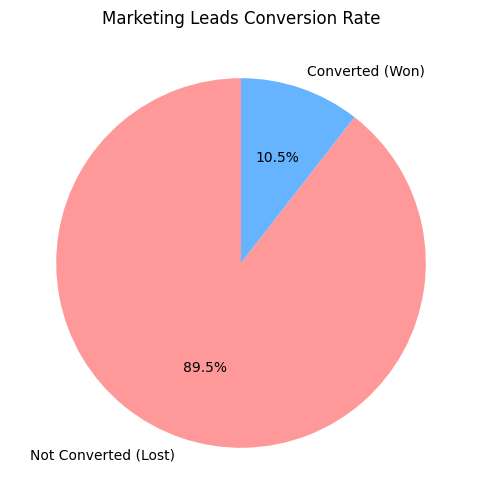

In [186]:
plt.figure(figsize=(8, 6))
conversion_counts = Fact_Marketing['is_converted'].value_counts()
plt.pie(conversion_counts, labels=['Not Converted (Lost)', 'Converted (Won)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Marketing Leads Conversion Rate')
plt.show()

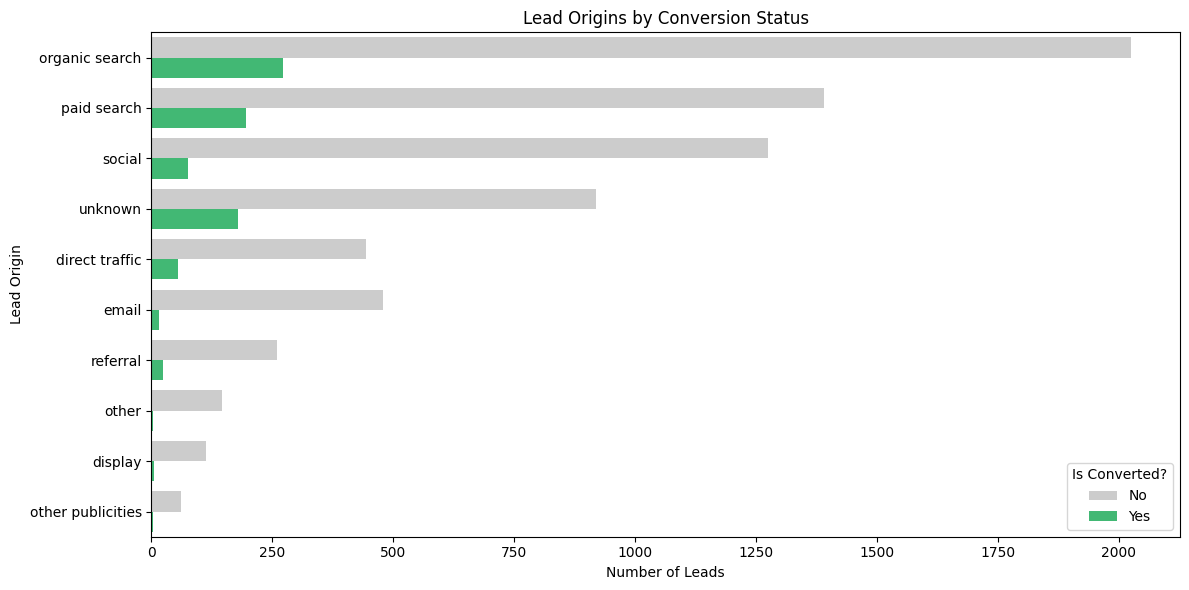

In [187]:
plt.figure(figsize=(12, 6))
sns.countplot(data=Fact_Marketing, y='lead_origin', hue='is_converted', 
              order=Fact_Marketing['lead_origin'].value_counts().index, 
              palette={False: '#cccccc', True: '#2ecc71'}) # رمادي للضائع، أخضر للناجح
plt.title('Lead Origins by Conversion Status')
plt.xlabel('Number of Leads')
plt.ylabel('Lead Origin')
plt.legend(title='Is Converted?', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

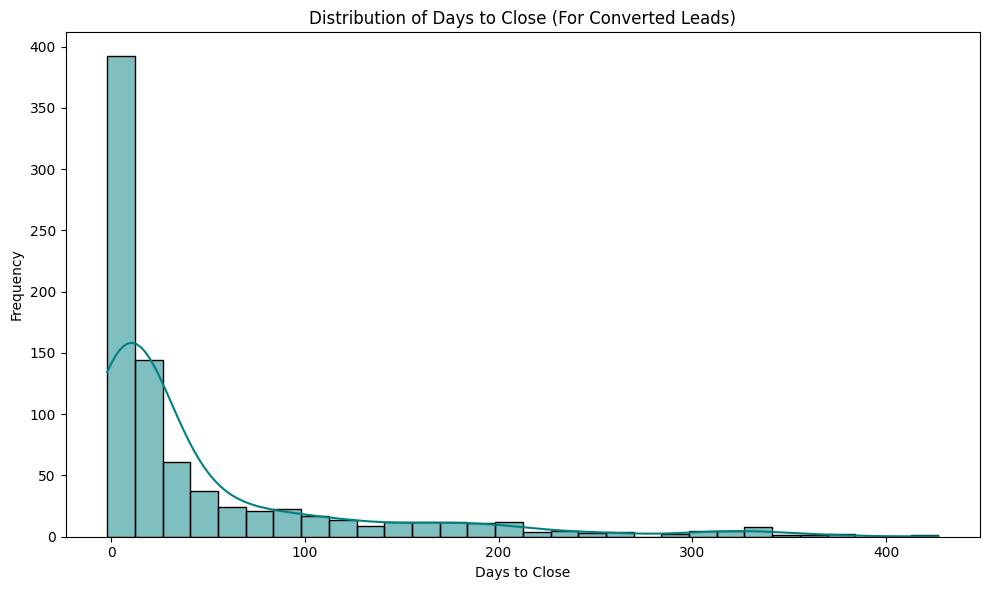

In [188]:
plt.figure(figsize=(10, 6))
sns.histplot(Fact_Marketing['days_to_close'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Days to Close (For Converted Leads)')
plt.xlabel('Days to Close')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()